In [1]:
# Training name
training_name = 'Transformer0e_2bit'

# Precision of input data
N_BITS = 2

In [5]:
# IMPORTS ---------------------------------------------------------------------

import warnings
warnings.filterwarnings("ignore")

import os, subprocess
from pathlib import Path
import random

from keras.utils import Sequence
from keras.callbacks import CSVLogger
from keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
colors = list(mcolors.TABLEAU_COLORS.keys())

from models import *
from plotting import *

2026-07-16 17:38:10.003680: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [6]:
# DATA ---------------------------------------------------------------------

dataset_base_dir = "/uscms/home/bweiss/nobackup/smart-pixels/"
tfrecords_base_dir = "/uscms/home/jennetd/nobackup/smart-pixels/tfrecords"

dataset_dir_val = os.path.join(dataset_base_dir, "dataset_3sr_16x16_50x12P5_centeredIncidence_parquets", 'test_contained/')
dataset_dir_test = os.path.join(dataset_base_dir, "dataset_2s_16x16_50x12P5_centeredIncidence_parquets", 'test_contained/')

In [4]:
seeds = grep('Seed','log_'+training_name+'.txt')
print("Seeds = ", seeds)

fingerprints = grep('Fingerprint','log_'+training_name+'.txt')
print("Fingerprints = ", fingerprints)
    
residuals = {}
best_epoch = {}

# BEGIN LOOP OVER NOISE ---------------------------------------------------------------------
for j,sigma in enumerate([0, 40, 80, 120, 240]):

    tfrecords_dir_val = os.path.join(tfrecords_base_dir, "TFR_val",'3sr_16x16_'+str(sigma)+'eNoise_test')
    residuals[sigma] = {}

    test_generator = OptimizedDataGenerator(
        load_from_tfrecords_dir= tfrecords_dir_val,
        shuffle=True,
        #seed=int(seeds[i]),
        quantize=False,
    )

    sf = test_generator.labels_scale

    scale_factor = {}
    scale_factor['x'] = sf[0]
    scale_factor['y'] = sf[1]
    scale_factor['cotA'] = sf[2]
    scale_factor['cotB'] = sf[3]
    
    # BEGIN LOOP OVER MODELS ---------------------------------------------------------------------
    for i in range(len(fingerprints)): 

        base_dir = '/uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-'+fingerprints[i]+'-'+training_name+'-checkpoints/'
    
        if not os.path.exists(base_dir):
            print("Fingerprint " + fingerprints[i] + " not found")
            continue
    
        checkpoint_dir = base_dir + 'checkpoints/'
        checkpoint_files = [os.path.join(checkpoint_dir, f) for f in os.listdir(checkpoint_dir) if f.endswith('.hdf5')]
        #latest_checkpoint = max(checkpoint_files, key=os.path.getmtime)
    
        checkpoint_val_loss = [float(f.split('-v')[1].split('.hdf5')[0]) for f in checkpoint_files]                      
        best_checkpoint = checkpoint_files[np.argmin(checkpoint_val_loss)]
        os.system('cp '+best_checkpoint+' ' +base_dir)

        best_epoch[i] = int(best_checkpoint.split('weights.')[1].split('-t')[0])

        model = create_vit_model(input_shape=(16,16,2),   
                                 patch_size=(3,4),        
                                 embed_dim=64,           
                                 num_heads=4,            
                                 ff_dim=128,              
                                 num_layers=4,            
                                 dropout=0.1,        
                                 n_bits=N_BITS,
                                 final_outputs=14         
                                )

        print(f"Loading model from {best_checkpoint}")
        model.load_weights(best_checkpoint)

        df = construct_df(model, test_generator, scale_factor)
        #df.to_parquet(base_dir+"residuals.parquet")
        residuals[sigma][i] = df


Seeds =  ['646', '575', '886', '553', '410']
Fingerprints =  ['31ac8cc6', '18109363', '66874c76', 'bb8a5790', '3739bb37']
Loading metadata from /uscms/home/jennetd/nobackup/smart-pixels/tfrecords/TFR_val/3sr_16x16_0eNoise_test/metadata.json


Loading model from /uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-31ac8cc6-Transformer0e_2bit-checkpoints/checkpoints/weights.4489-t-51068.46-v-53185.32.hdf5
21/21 [==============================] - 11s 479ms/step


100%|██████████| 21/21 [00:01<00:00, 16.04it/s]


0.20174779 -0.60974187 1.0162302
Loading model from /uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-18109363-Transformer0e_2bit-checkpoints/checkpoints/weights.4935-t-51560.16-v-53399.13.hdf5
21/21 [==============================] - 3s 140ms/step


100%|██████████| 21/21 [00:03<00:00,  6.52it/s]


...

0.2017666 -0.60974187 1.0162302
Loading model from /uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-bb8a5790-Transformer0e_2bit-checkpoints/checkpoints/weights.4886-t-50899.42-v-53031.61.hdf5
21/21 [==============================] - 3s 139ms/step


100%|██████████| 21/21 [00:01<00:00, 18.05it/s]


0.2017666 -0.60974187 1.0162302
Loading model from /uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-3739bb37-Transformer0e_2bit-checkpoints/checkpoints/weights.4631-t-51525.82-v-53441.88.hdf5
21/21 [==============================] - 3s 137ms/step


100%|██████████| 21/21 [00:01<00:00, 19.65it/s]


0.2017666 -0.60974187 1.0162302


0 0
0 1
0 2
0 3
0 4
40 0
40 1
40 2
40 3
40 4
80 0
80 1
80 2
80 3
80 4
120 0
120 1
120 2
120 3
120 4
240 0
240 1
240 2
240 3
240 4


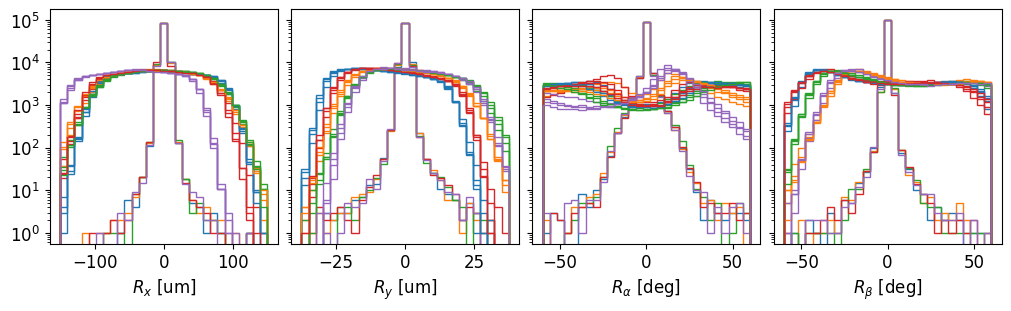

In [5]:
# OVERLAY RESIDUALS OF ALL TRAININGS --------------------------------------

# Pixel pitch (um)
xpitch = 50
ypitch = 12.5
# Thickness (um)
D = 100
# Size of pixel array
lenx = 16
leny = 16

cols = []
for v in ['x','y','A','B','cotA','cotB']:
    cols = cols + ['mean_'+v, 'std_'+v, 'up68_'+v, 'down68_'+v]
avg_residuals = pd.DataFrame(None, index=np.arange(len(fingerprints)),columns=cols)

fig, ax = plt.subplots(1,4,figsize=(10,3),sharey='row', constrained_layout=True)

for sigma, d in residuals.items():

    for i, df in d.items():

        print(sigma, i)

        # x
        ax[0].set_xlabel(r'$R_x$ [um]')
        ax[0].hist(df["residualx"],histtype='step',bins=np.linspace(-3*xpitch,3*xpitch,30),color=colors[i])
        ax[0].set_yscale('log')

        # y
        ax[1].set_xlabel(r'$R_y$ [um]')
        ax[1].hist(df["residualy"],histtype='step',bins=np.linspace(-3*ypitch,3*ypitch,30),color=colors[i])

        # alpha
        ax[2].set_xlabel(r'$R_\alpha$ [deg]')
        ax[2].hist(df["residualA"],histtype='step',bins=np.linspace(-60,60,30),color=colors[i])
        
        # beta
        ax[3].set_xlabel(r'$R_\beta$ [deg]')
        ax[3].hist(df["residualB"],histtype='step',bins=np.linspace(-60,60,30),color=colors[i])
      
        # Residuals for x and y (microns)
        for v in ['x','y','A','cotA','B','cotB']:
            # Mean
            avg_residuals['mean_'+v].iloc[i] = float(np.mean(df['residual'+v]))
            # Std -- replace with smallest window containing 68%
            avg_residuals['std_'+v].iloc[i] = float(np.std(df['residual'+v]))

            interval68 = shortest_interval_68(df['residual'+v], center_type='mean')
            avg_residuals['up68_'+v].iloc[i] = interval68['error_high']
            avg_residuals['down68_'+v].iloc[i] = interval68['error_low']

    # Need to save a different file per noise value
    avg_residuals.to_parquet("avg_res_Transformer_Nom"+str(sigma)+"e.parquet")


In [7]:
seeds = grep('Seed','log_'+training_name+'.txt')
print("Seeds = ", seeds)

fingerprints = grep('Fingerprint','log_'+training_name+'.txt')
print("Fingerprints = ", fingerprints)
    
residuals = {}
best_epoch = {}

# BEGIN LOOP OVER NOISE ---------------------------------------------------------------------
for j,sigma in enumerate([0, 40, 80, 120, 240]):

    tfrecords_dir_test = os.path.join(tfrecords_base_dir, "TFR_test",'2s_16x16_'+str(sigma)+'eNoise_test')
    residuals[sigma] = {}

    test_generator = OptimizedDataGenerator(
        load_from_tfrecords_dir= tfrecords_dir_test,
        shuffle=True,
        #seed=int(seeds[i]),
        quantize=False,
    )

    sf = test_generator.labels_scale

    scale_factor = {}
    scale_factor['x'] = sf[0]
    scale_factor['y'] = sf[1]
    scale_factor['cotA'] = sf[2]
    scale_factor['cotB'] = sf[3]
    
    # BEGIN LOOP OVER MODELS ---------------------------------------------------------------------
    for i in range(len(fingerprints)): 

        base_dir = '/uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-'+fingerprints[i]+'-'+training_name+'-checkpoints/'
    
        if not os.path.exists(base_dir):
            print("Fingerprint " + fingerprints[i] + " not found")
            continue
    
        checkpoint_dir = base_dir + 'checkpoints/'
        checkpoint_files = [os.path.join(checkpoint_dir, f) for f in os.listdir(checkpoint_dir) if f.endswith('.hdf5')]
        #latest_checkpoint = max(checkpoint_files, key=os.path.getmtime)
    
        checkpoint_val_loss = [float(f.split('-v')[1].split('.hdf5')[0]) for f in checkpoint_files]                      
        best_checkpoint = checkpoint_files[np.argmin(checkpoint_val_loss)]
        os.system('cp '+best_checkpoint+' ' +base_dir)

        best_epoch[i] = int(best_checkpoint.split('weights.')[1].split('-t')[0])

        model = create_vit_model(input_shape=(16,16,2),   
                                 patch_size=(3,4),        
                                 embed_dim=64,           
                                 num_heads=4,            
                                 ff_dim=128,              
                                 num_layers=4,            
                                 dropout=0.1,        
                                 n_bits=N_BITS,
                                 final_outputs=14         
                                )

        print(f"Loading model from {best_checkpoint}")
        model.load_weights(best_checkpoint)

        df = construct_df(model, test_generator, scale_factor, is2s = True)
        #df.to_parquet(base_dir+"residuals.parquet")
        residuals[sigma][i] = df


Seeds =  ['646', '575', '886', '553', '410']
Fingerprints =  ['31ac8cc6', '18109363', '66874c76', 'bb8a5790', '3739bb37']
Loading metadata from /uscms/home/jennetd/nobackup/smart-pixels/tfrecords/TFR_test/2s_16x16_0eNoise_test/metadata.json


Loading model from /uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-31ac8cc6-Transformer0e_2bit-checkpoints/checkpoints/weights.4489-t-51068.46-v-53185.32.hdf5
278/278 [==============================] - 63s 226ms/step


100%|██████████| 278/278 [00:16<00:00, 16.40it/s]


0.20340809 -0.6087434 1.0145767
Loading model from /uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-18109363-Transformer0e_2bit-checkpoints/checkpoints/weights.4935-t-51560.16-v-53399.13.hdf5
278/278 [==============================] - 36s 129ms/step


100%|██████████| 278/278 [00:15<00:00, 17.95it/s]


...

0.2034043 -0.6087434 1.0145767
Loading model from /uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-bb8a5790-Transformer0e_2bit-checkpoints/checkpoints/weights.4886-t-50899.42-v-53031.61.hdf5
278/278 [==============================] - 37s 130ms/step


100%|██████████| 278/278 [00:15<00:00, 17.62it/s]


0.2034043 -0.6087434 1.0145767
Loading model from /uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-3739bb37-Transformer0e_2bit-checkpoints/checkpoints/weights.4631-t-51525.82-v-53441.88.hdf5
278/278 [==============================] - 38s 137ms/step


100%|██████████| 278/278 [00:15<00:00, 17.54it/s]


0.2034043 -0.6087434 1.0145767


0 0
0 1
0 2
0 3
0 4
40 0
40 1
40 2
40 3
40 4
80 0
80 1
80 2
80 3
80 4
120 0
120 1
120 2
120 3
120 4
240 0
240 1
240 2
240 3
240 4


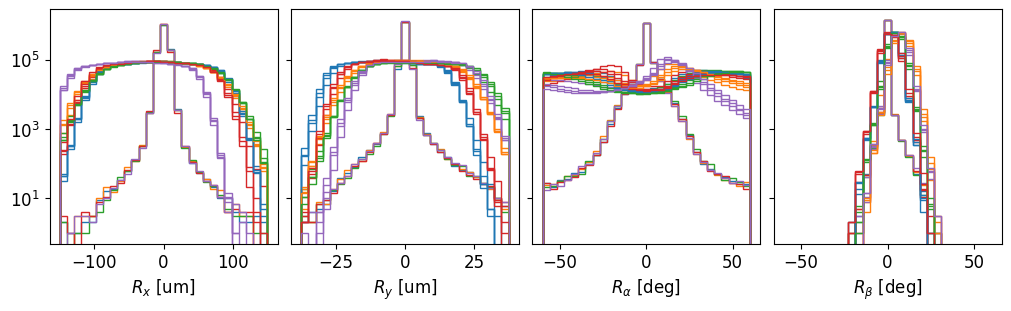

In [8]:
# OVERLAY RESIDUALS OF ALL TRAININGS --------------------------------------

# Pixel pitch (um)
xpitch = 50
ypitch = 12.5
# Thickness (um)
D = 100
# Size of pixel array
lenx = 16
leny = 16

cols = []
for v in ['x','y','A','B','cotA','cotB']:
    cols = cols + ['mean_'+v, 'std_'+v, 'up68_'+v, 'down68_'+v]
avg_residuals = pd.DataFrame(None, index=np.arange(len(fingerprints)),columns=cols)

fig, ax = plt.subplots(1,4,figsize=(10,3),sharey='row', constrained_layout=True)

for sigma, d in residuals.items():

    for i, df in d.items():

        print(sigma, i)

        # x
        ax[0].set_xlabel(r'$R_x$ [um]')
        ax[0].hist(df["residualx"],histtype='step',bins=np.linspace(-3*xpitch,3*xpitch,30),color=colors[i])
        ax[0].set_yscale('log')

        # y
        ax[1].set_xlabel(r'$R_y$ [um]')
        ax[1].hist(df["residualy"],histtype='step',bins=np.linspace(-3*ypitch,3*ypitch,30),color=colors[i])

        # alpha
        ax[2].set_xlabel(r'$R_\alpha$ [deg]')
        ax[2].hist(df["residualA"],histtype='step',bins=np.linspace(-60,60,30),color=colors[i])
        
        # beta
        ax[3].set_xlabel(r'$R_\beta$ [deg]')
        ax[3].hist(df["residualB"],histtype='step',bins=np.linspace(-60,60,30),color=colors[i])
      
        # Residuals for x and y (microns)
        for v in ['x','y','A','cotA','B','cotB']:
            # Mean
            avg_residuals['mean_'+v].iloc[i] = float(np.mean(df['residual'+v]))
            # Std -- replace with smallest window containing 68%
            avg_residuals['std_'+v].iloc[i] = float(np.std(df['residual'+v]))

            interval68 = shortest_interval_68(df['residual'+v], center_type='mean')
            avg_residuals['up68_'+v].iloc[i] = interval68['error_high']
            avg_residuals['down68_'+v].iloc[i] = interval68['error_low']

    # Need to save a different file per noise value
    avg_residuals.to_parquet("avg_res_2s_Transformer_Nom"+str(sigma)+"e.parquet")